In [111]:
##This notebook is now older (can safely ignore it for the newer notebooks written in Feb 2026)

import fastplotlib as fpl
import os
import masknmf
import sys
import numpy as np

from ipywidgets import HBox, VBox
import math
import torch

##In the existing folder
import iblwfci_vis
import iblwfci_utils

from tqdm import tqdm
from one.api import ONE
from brainbox.io.one import SessionLoader
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
one = ONE()

%load_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [112]:
"""
The two datasets from FD that we will process are: 
(1) 71ceb3d4-ca68-4380-8fe7-9f63d26222f6 (This is the existing FD_24/2023-06-07/001 data that I had already downloaded) (outputs are in the 007 folder)
(2) 8df7b200-e44c-4c67-82e9-2666ba05d649 (This is the  FD_24/2023-06-08/001 data) (outputs are in the 008 folder)
"""

'\nThe two datasets from FD that we will process are: \n(1) 71ceb3d4-ca68-4380-8fe7-9f63d26222f6 (This is the existing FD_24/2023-06-07/001 data that I had already downloaded)\n(2) 8df7b200-e44c-4c67-82e9-2666ba05d649 (This is the  FD_24/2023-06-08/001 data)\n'

# Step 1: Let's load the trial data we need from ONE to do the trial-triggered analysis 

In [1]:
eid = "8df7b200-e44c-4c67-82e9-2666ba05d649"
sl = SessionLoader(eid = eid, one=one)
sl.load_trials()
print(sl.trials.keys())
stim_ontimes = sl.trials['stimOn_times']
firstMovement = sl.trials['firstMovement_times'].to_numpy()
firstMovement = firstMovement[~np.isnan(firstMovement)]
feedback_times = sl.trials['feedback_times'].to_numpy()
sl.load_motion_energy() ## Load Motion Energy seems to fail here, not sure why 

sl.load_wheel()
imaging_times = one.load_dataset(eid, "imaging.times.npy", collection="alf/widefield")

In [132]:
def keep_separated(timepoints, min_sep=2.0):
    """
    Keep a subset of timepoints such that each is at least `min_sep`
    seconds apart from the previously kept one.

    Parameters
    ----------
    timepoints : array-like
        List or array of timepoints (in seconds).
    min_sep : float
        Minimum separation in seconds.

    Returns
    -------
    kept : list
        Subset of timepoints satisfying the separation constraint.
    """
    if len(timepoints) == 0:
        return []

    # Ensure sorted order
    timepoints = sorted(timepoints)

    kept = [timepoints[0]]
    last = timepoints[0]

    for t in timepoints[1:]:
        if t - last >= min_sep:
            kept.append(t)
            last = t

    return kept

def load_wheel_speed_trials(wheel_info, imaging_times):
    times = wheel_info['times'].to_numpy()
    velocity = wheel_info['velocity'].to_numpy()

    selector = np.logical_and(times > 5, np.abs(velocity) > 4)
    selector = np.logical_and(selector, times < np.amax(imaging_times) - 100) #Guarantee we are still in the right window
    subset_times = times[selector]
    subset_times = keep_separated(subset_times, min_sep=2.0)
    return np.array(subset_times)


def load_whisker_motion_trials(whisker_motion, imaging_times):
    times = whisker_motion['times'].to_numpy()
    energy = whisker_motion['whiskerMotionEnergy'].to_numpy()
    print(np.amax(energy))

    selector = np.logical_and(times > 5, np.abs(energy) > 10)
    selector = np.logical_and(selector, times < np.amax(imaging_times) - 100)
    subset_times = times[selector]
    subset_times = keep_separated(subset_times, min_sep=2.0)
    return np.array(subset_times)

wheel_trials = load_wheel_speed_trials(sl.wheel, imaging_times)
whisker_trials = load_whisker_motion_trials(sl.motion_energy['leftCamera'], imaging_times)
print(len(whisker_trials))
print(len(wheel_trials))

49.949092864990234
1460
328


In [92]:
sl.motion_energy['leftCamera']

,times,whiskerMotionEnergy
0,1.264400,0.000000
1,1.279400,0.000000
2,1.296100,0.000000
3,1.312833,0.000000
4,1.329533,0.000000
...,...,...
254866,4261.969467,4.140441
254867,4261.986200,0.046102
254868,4262.002900,4.173371
254869,4262.019633,6.422986


In [89]:
np.amax(sl.motion_energy['leftCamera']['whiskerMotionEnergy'].to_numpy())

np.float64(49.615997314453125)

In [119]:
hemocorr_pmd.shape

(np.int64(133053), np.int64(540), np.int64(640))

In [158]:
np.searchsorted(np.array([1, 3, 4]), np.array(([2, 3.5, 100])))

array([1, 2, 3])

In [133]:
def extract_time_aligned_behavior(imaging_times, functional_channel, behavior_times, behavior_values):
   
    functional_times = imaging_times[functional_channel::2]

    time_subset = np.logical_and(behavior_times < np.amax(functional_times), behavior_times > np.amin(imaging_times))
    behavior_times = behavior_times[time_subset]
    behavior_values = behavior_values[time_subset]
    behavior_indices = np.searchsorted(behavior_times, functional_times)
    behavior_indices[behavior_indices >= behavior_values.shape[0]] = behavior_values.shape[0] - 1
    behavior_indices[behavior_indices < 0] = 0
    # print(np.amax(behavior_indices))
    # print(behavior_values.shape)
    final_behavior_values = behavior_values[behavior_indices]
    return final_behavior_values

def compute_correlation_map(pmd_obj,trace, exclusion=10, device='cpu', batch_size = 40):
    trace = torch.from_numpy(trace[exclusion:exclusion*-1]).to(device)
    trace -= torch.mean(trace)
    trace /= torch.linalg.norm(trace)

    height_iters = math.ceil(pmd_obj.shape[1] / batch_size)
    width_iters = math.ceil(pmd_obj.shape[2] / batch_size)

    corr_map = torch.zeros(pmd_obj.shape[1], pmd_obj.shape[2]).to(device)
    for k in tqdm(range(height_iters)):
        for j in range(width_iters):
            dim1 = slice(k * batch_size, min((k+1)*batch_size, pmd_obj.shape[1]))
            dim2 = slice(j * batch_size, min((j+1)*batch_size, pmd_obj.shape[2]))
            my_data = pmd_obj.getitem_tensor((slice(exclusion, pmd_obj.shape[0] - exclusion), dim1, dim2))
            my_data -= torch.mean(my_data, dim=0, keepdim=True)
            my_data /= torch.linalg.norm(my_data, dim=0, keepdim=True)
            my_data = torch.nan_to_num(my_data, nan = 0.0)

            corr_map[dim1, dim2] = torch.sum(my_data * trace[:, None, None], dim = 0)
    return corr_map.cpu().numpy()
            
            


In [141]:
corr_map_amol *= manual_mask
corr_map_joao *= manual_mask

In [2]:
trial_indices_abs = np.searchsorted(imaging_times, wheel_trials)
trial_indices = (trial_indices_abs // 2) ##This is correct if the functional channel is 0. If it is 1, you need to adjust it
before_frames = 20
after_frames = 40

# behavior_values = extract_time_aligned_behavior(imaging_times,
#                                                 0,
#                                                 sl.motion_energy['leftCamera']['times'].to_numpy(),
#                                                 sl.motion_energy['leftCamera']['whiskerMotionEnergy'].to_numpy())

# print(np.amin(imaging_times))
# print(np.amax(imaging_times))
# print(np.amin(sl.wheel['times'].to_numpy()))
# print(np.amax(sl.wheel['times'].to_numpy()))
# behavior_values = extract_time_aligned_behavior(imaging_times,
#                                                 0,
#                                                 sl.wheel['times'].to_numpy(),
#                                                 sl.wheel['velocity'].to_numpy())


# corr_map_amol = manual_mask * compute_correlation_map(hemocorr_pmd, behavior_values, exclusion=20000, device='cuda')
# corr_map_joao = manual_mask * compute_correlation_map(joao_hemocorr, behavior_values, exclusion=20000, device='cuda')

# # behavior_var = sl.wheel['times']
# behavior_var = sl.motion_energy['leftCamera']['whiskerMotionEnergy']
# behavior_times = sl.motion_energy['leftCamera']['times']
# ### Below code just loads the appropriate stuff for the wheel trials data
# """
# We multiply by 2 because there are two channels
# """
# diff_val = np.arange(-1 * before_frames, after_frames)[:, None]
# frames_to_index = 2*(diff_val + trial_indices[None, :])
# frames_to_index_f = frames_to_index.flatten()
# times_for_frames = imaging_times[frames_to_index_f]

# print(frames_to_index_f.shape)
# print(times_for_frames.shape)

# print(np.amax(behave_indices))
# print(behavior_var.to_numpy().shape)

# behave_indices = np.searchsorted(behavior_times.to_numpy(), times_for_frames)
# behave_values_f = behavior_var.to_numpy()[behave_indices]
# behave_values = behave_values_f.reshape(frames_to_index.shape)
# behave_trial_avg = np.mean(behave_values, axis = 1)

# print(behave_trial_avg)

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
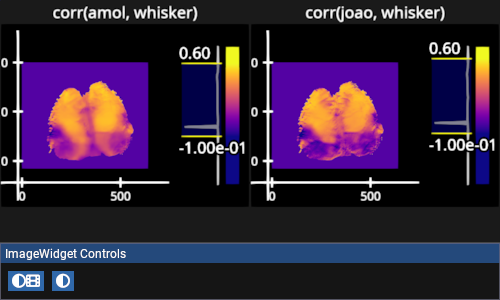

In [186]:
iw = fpl.ImageWidget(data = [corr_map_amol, corr_map_joao * manual_mask],
                    names = ['corr(amol, whisker)', 'corr(joao, whisker)'])
for graphic in iw.managed_graphics:
    graphic.vmin = -0.1
    graphic.vmax = 0.6

iw.show()

# Step 2: Let's load the stacks we need (from Joao's method and Amol's method) to study trial-trigged signal

In [135]:
## Let's load the 007 folder data (masknmf processing results)
hemocorr_pmd = masknmf.PMDArray.from_hdf5("felicia_jan_26_008/hemocorr.hdf5")
hemocorr_pmd.to('cuda')
hemocorr_pmd.rescale = True

gcamp_pmd = masknmf.PMDArray.from_hdf5("felicia_jan_26_008/gcamp.hdf5")
gcamp_pmd.to('cuda')
gcamp_pmd.rescale = True

blood_pmd = masknmf.PMDArray.from_hdf5("felicia_jan_26_008/blood.hdf5")
blood_pmd.to('cuda')
blood_pmd.rescale = True

In [148]:
parent_path = "/data/lab/IBL_Alyx/churchlandlab_ucla/Subjects/FD_24/2023-06-08/001/raw_widefield_data"
u_path = os.path.join(parent_path, "U.npy")
svt_path = os.path.join(parent_path, "SVT.npy")
svtcorr_path = os.path.join(parent_path, "SVTcorr.npy")
frames_avg_path = os.path.join(parent_path, "frames_average.npy")

manual_mask = np.load(os.path.join(parent_path, "manual_mask.npy"))

In [137]:
joao_gcamp, joao_blood, joao_hemocorr = iblwfci_utils.load_joao_results(u_path,
                  svt_path,
                  svtcorr_path,
                  frames_avg_path,
                  functional_channel = 0)

In [138]:
joao_gcamp.rescale = True
joao_blood.rescale = True
joao_hemocorr.rescale = True 

joao_gcamp.to('cuda')
joao_blood.to('cuda')
joao_hemocorr.to('cuda')

In [120]:
def get_trial_triggered_stack(my_pmd_movie, trial_indices, before_frames = 20, after_frames = 100, device='cpu', normalizer = True):
    my_pmd_movie.to(device)
    average_movie = torch.zeros((before_frames + after_frames, my_pmd_movie.shape[1], my_pmd_movie.shape[2])).to(device)
    num_trials = trial_indices.shape[0]
    if normalizer is not None:
        normalizer = torch.from_numpy(normalizer).to(device)
        normalizer[normalizer == 0] = 1.0 
    else:
        normalizer = torch.ones(my_pmd_movie.shape[1], my_pmd_movie.shape[2], device='cuda').float()
    for k in tqdm(range(trial_indices.shape[0])):
        curr_ind = trial_indices[k]
        curr_data = my_pmd_movie.getitem_tensor(slice(curr_ind - before_frames, curr_ind + after_frames)) 
        curr_data /= num_trials
        average_movie += curr_data 
    return torch.nan_to_num(average_movie / normalizer, nan = 0.0).cpu().numpy()


def get_trial_triggered_stack_binary_xcorr(my_pmd_movie, trial_indices, mean_img, before_frames = 20, after_frames = 100, device='cpu', normalizer = True):
    my_pmd_movie.to(device)
    average_movie = torch.zeros((before_frames + after_frames, my_pmd_movie.shape[1], my_pmd_movie.shape[2])).to(device)
    num_trials = trial_indices.shape[0]
    if normalizer is not None:
        normalizer = torch.from_numpy(normalizer).to(device)
        normalizer[normalizer == 0] = 1.0 
    else:
        normalizer = torch.ones(my_pmd_movie.shape[1], my_pmd_movie.shape[2], device='cuda').float()
    for k in tqdm(range(trial_indices.shape[0])):
        curr_ind = trial_indices[k]
        curr_data = my_pmd_movie.getitem_tensor(slice(curr_ind - before_frames, curr_ind + after_frames)) 
        curr_data /= my_pmd_movie.shape[0]
        average_movie += curr_data 
    numerator = average_movie - (num_trials / my_pmd_movie.shape[0])*torch.from_numpy(mean_img).to(device).float()
    numerator = torch.nan_to_num(numerator / normalizer[None, :, :], nan = 0.0)
    test_vec = torch.zeros(my_pmd_movie.shape[0], device = 'cuda').float()
    test_vec[:num_trials] = 1
    std_val = torch.std(test_vec)
    print(std_val)
    numerator = torch.nan_to_num(numerator / std_val, nan = 0.0)
    return numerator.cpu().numpy()



def compute_std_img(pmd_obj, device = 'cuda', batch_size = 40):
    
    height_iters = math.ceil(pmd_obj.shape[1] / batch_size)
    width_iters = math.ceil(pmd_obj.shape[2] / batch_size)

    std_map = torch.zeros(pmd_obj.shape[1], pmd_obj.shape[2]).to(device)
    mean_map = torch.zeros(pmd_obj.shape[1], pmd_obj.shape[2]).to(device)
    for k in tqdm(range(height_iters)):
        for j in range(width_iters):
            dim1 = slice(k * batch_size, min((k+1)*batch_size, pmd_obj.shape[1]))
            dim2 = slice(j * batch_size, min((j+1)*batch_size, pmd_obj.shape[2]))
            my_data = pmd_obj.getitem_tensor((slice(0, pmd_obj.shape[0]), dim1, dim2))
            std_map[dim1, dim2] = torch.std(my_data, dim = 0)
            mean_map[dim1, dim2] = torch.mean(my_data, dim = 0)
        
    return std_map.cpu().numpy(), mean_map.cpu().numpy()



In [139]:
joao_hemo_std_img, joao_hemo_mean_img = compute_std_img(joao_hemocorr)
amol_hemo_std_img, amol_hemo_mean_img = compute_std_img(hemocorr_pmd)

joao_blood_std_img, joao_blood_mean_img = compute_std_img(joao_blood)
amol_blood_std_img, amol_blood_mean_img = compute_std_img(blood_pmd)

joao_gcamp_std_img, joao_gcamp_mean_img = compute_std_img(joao_gcamp)
amol_gcamp_std_img, amol_gcamp_mean_img = compute_std_img(gcamp_pmd)


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 14/14 [00:14<00:00,  1.02s/it]


In [34]:
np.amax(amol_std_img)
np.amin(amol_std_img)

np.float32(0.0)

In [183]:
# def compute_average_trial_correlations(trial_avg_movie: np.ndarray,
#                                        my_pmd_movie,
#                                        trial_indices,
#                                        mask = None,
#                                        before_frames = 20,
#                                        after_frames = 80,
#                                        device = 'cuda'):

#     if mask is None:
#         mask = torch.ones(my_pmd_movie.shape[1], my_pmd_movie.shape[2]).float().to(device)
#     else:
#         mask = torch.from_numpy(mask).float().to(device)
#     my_pmd_movie.to(device)
#     average_movie = torch.from_numpy(trial_avg_movie).to(device).float() * mask[None, :, :]
#     average_movie -= torch.mean(average_movie, dim = 0, keepdim=True)
#     average_movie /= torch.linalg.norm(average_movie, dim=0, keepdim=True)
#     average_movie = torch.nan_to_num(average_movie, nan = 0.0)
#     average_correlation = torch.zeros(my_pmd_movie.shape[1], my_pmd_movie.shape[2], device=device).float()
#     num_trials = trial_indices.shape[0]
#     avg_list = []
#     for k in tqdm(range(trial_indices.shape[0])):
#         curr_ind = trial_indices[k]
#         curr_data = my_pmd_movie.getitem_tensor(slice(curr_ind - before_frames, curr_ind + after_frames)) * mask[None, :, :]
#         curr_data -= torch.mean(curr_data, dim=0, keepdim=True)
#         curr_data /= torch.linalg.norm(curr_data, dim=0, keepdim=True)
#         curr_data = torch.nan_to_num(curr_data, nan = 0.0)
#         temp = (torch.sum(curr_data * average_movie, dim = 0))
#         avg_list.append(torch.amax(temp[mask >= 0]).cpu().numpy())
#         average_correlation += (torch.nan_to_num(temp, nan = 0.0) / num_trials)

#     return average_correlation.cpu().numpy(), np.array(avg_list)

In [90]:
joao_std_img.shape
amol_mean_img.device

'cpu'

In [28]:
hemocorr_pmd.rescale

True

In [141]:
joao_trial_avg = get_trial_triggered_stack(joao_hemocorr, trial_indices, before_frames = before_frames, after_frames = after_frames, device='cuda', normalizer = joao_std_img)

In [ ]:
amol_trial_avg = get_trial_triggered_stack(hemocorr_pmd, trial_indices, before_frames = before_frames, after_frames = after_frames, device='cuda', normalizer=amol_std_img)

# Below are images computed via correlations

In [151]:
amol_hemo_trial_avg =  get_trial_triggered_stack_binary_xcorr(hemocorr_pmd, 
                                                              trial_indices, 
                                                              amol_hemo_mean_img, 
                                                              before_frames = before_frames, 
                                                              after_frames = after_frames, 
                                                              device='cuda', 
                                                              normalizer=amol_hemo_std_img)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 328/328 [00:02<00:00, 147.79it/s]


tensor(0.0539, device='cuda:0')


In [152]:
joao_hemo_trial_avg =  get_trial_triggered_stack_binary_xcorr(joao_hemocorr, 
                                                         trial_indices, 
                                                         joao_hemo_mean_img, 
                                                         before_frames = before_frames, 
                                                         after_frames = after_frames, 
                                                         device='cuda', 
                                                         normalizer=joao_hemo_std_img)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 328/328 [00:13<00:00, 25.21it/s]


tensor(0.0539, device='cuda:0')


In [153]:
amol_gcamp_trial_avg = get_trial_triggered_stack_binary_xcorr(gcamp_pmd, 
                                                              trial_indices, 
                                                              amol_gcamp_mean_img, 
                                                              before_frames = before_frames, 
                                                              after_frames = after_frames, 
                                                              device='cuda', 
                                                              normalizer=amol_gcamp_std_img)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 328/328 [00:02<00:00, 150.39it/s]


tensor(0.0539, device='cuda:0')


In [154]:
joao_gcamp_trial_avg =  get_trial_triggered_stack_binary_xcorr(joao_gcamp, 
                                                         trial_indices, 
                                                         joao_gcamp_mean_img, 
                                                         before_frames = before_frames, 
                                                         after_frames = after_frames, 
                                                         device='cuda', 
                                                         normalizer=joao_gcamp_std_img)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 328/328 [00:13<00:00, 24.93it/s]


tensor(0.0539, device='cuda:0')


In [155]:
amol_blood_trial_avg =  get_trial_triggered_stack_binary_xcorr(blood_pmd, 
                                                              trial_indices, 
                                                              amol_blood_mean_img, 
                                                              before_frames = before_frames, 
                                                              after_frames = after_frames, 
                                                              device='cuda', 
                                                              normalizer=amol_blood_std_img)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 328/328 [00:02<00:00, 158.09it/s]


tensor(0.0539, device='cuda:0')


In [156]:
joao_blood_trial_avg =  get_trial_triggered_stack_binary_xcorr(joao_blood, 
                                                             trial_indices, 
                                                             joao_blood_mean_img, 
                                                             before_frames = before_frames, 
                                                             after_frames = after_frames, 
                                                             device='cuda', 
                                                             normalizer=joao_blood_std_img)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 328/328 [00:13<00:00, 24.69it/s]


tensor(0.0539, device='cuda:0')


In [1]:
iw = fpl.ImageWidget(data = [manual_mask * (amol_hemo_trial_avg),
                             manual_mask*(joao_hemo_trial_avg),
                             manual_mask*(amol_gcamp_trial_avg),
                            manual_mask*(joao_gcamp_trial_avg),
                            manual_mask*(amol_blood_trial_avg),
                            manual_mask*(joao_blood_trial_avg)],
                     names = ['amol hemo wheel triggered',
                              'joao hemo wheel triggered',
                              'amol gcamp wheel triggered',
                              'joao gcamp wheel triggered',
                              'amol blood wheel triggered',
                              'joao blood wheel triggered'],
                     figure_shape = (3, 2),
                    histogram_widget=True)


iw.cmap = "gray"
iw.show()

## Let's look at the pixelwise correlation matrices

In [180]:
subsampled_data = hemocorr_pmd[:, ::10, ::10]

In [161]:
subsampled_data.shape

(112579, 54, 64)

In [160]:
joao_subsampled = joao_hemocorr[:, ::10, ::10]

In [185]:
def compute_pixel_corr_mat(mat_orig, manual_mask):
    mat = manual_mask[None, :, :] * mat_orig
    mat = mat.reshape(mat.shape[0], -1)
    mat -= np.mean(mat, axis = 0, keepdims = True)
    norms = np.linalg.norm(mat, axis = 0, keepdims = True)
    norms[norms <= 0] = 1.0
    mat /= norms
    mat = np.nan_to_num(mat, nan = 0)
    corr = mat.T @ mat
    return corr

amol_corr = compute_pixel_corr_mat(subsampled_data[20000:-20000, :, :], manual_mask[::10, ::10])


In [186]:
joao_corr = compute_pixel_corr_mat(joao_subsampled[20000:-20000, :, :], manual_mask[::10, ::10])

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
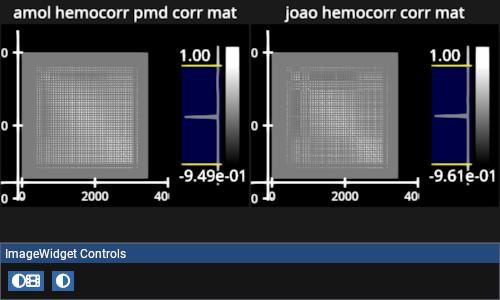

In [187]:
iw = fpl.ImageWidget(data = [amol_corr, joao_corr],
                    names = ['amol hemocorr pmd corr mat', 'joao hemocorr corr mat'])
iw.cmap = "gray"
iw.show()

In [58]:
num_trials = trial_indices.shape[0]
print(num_trials)

test = np.zeros(hemocorr_pmd.shape[0])
test[:num_trials] = 1

std_val = np.std(test)
print(std_val)

948
0.08410835230318922


RFBOutputContext()

/data/home/app2139/wfield/wfieldvenv/lib/python3.11/site-packages/fastplotlib/graphics/features/_base.py:18: UserWarning: casting float64 array to float32
  warn(f"casting {array.dtype} array to float32")


JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
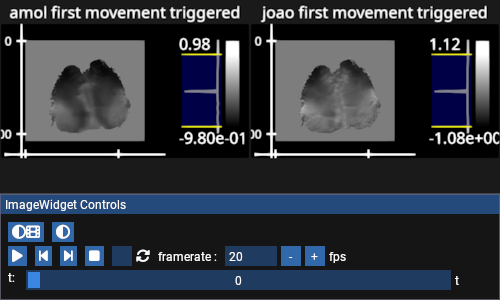

In [54]:
iw = fpl.ImageWidget(data = [manual_mask * (amol_trial_avg - np.mean(amol_trial_avg, axis = 0, keepdims=True)),
                             manual_mask*(joao_trial_avg - np.mean(joao_trial_avg, axis = 0, keepdims = True))],
                     names = ['amol first movement triggered', 'joao first movement triggered'],
                    histogram_widget=True)


iw.cmap = "gray"
iw.show()

In [57]:
wheel_trial_avg.shape

(100,)

In [98]:
## Given the trial averaged movies, compute the correlation between the behavioral signal and the trial averaged signal
def correlate_trial_avg_with_expt_signal(trial_avg_movie,
                                         signal_of_interest):
    trial_mean0 = trial_avg_movie - np.mean(trial_avg_movie, axis = 0, keepdims=True)
    trial_mean0 /= np.linalg.norm(trial_mean0, axis = 0, keepdims=True)
    trial_mean0 = np.nan_to_num(trial_mean0, nan = 0.0)
    signal_of_interest_mean0 = signal_of_interest - np.mean(signal_of_interest)
    signal_of_interest_mean0 /= np.linalg.norm(signal_of_interest_mean0)

    print(trial_mean0.shape)
    print(signal_of_interest_mean0.shape)
    return np.sum(trial_mean0 * signal_of_interest_mean0[:, None, None], axis = 0) 

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
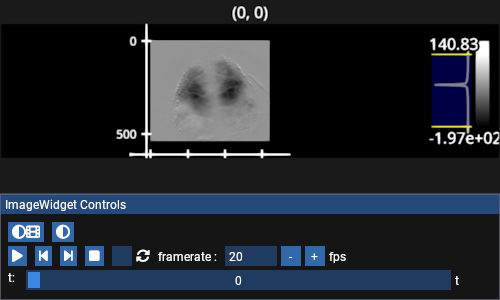

In [187]:
iw = fpl.ImageWidget(data = joao_trial_avg)
iw.cmap = "gray"
iw.show()

## Let's try correlating behavioral variable directly with each time series

device(type='cuda', index=0)

In [99]:
amol_trial_avg_corr = correlate_trial_avg_with_expt_signal(amol_trial_avg,
                                                           behave_trial_avg)
joao_trial_avg_corr = correlate_trial_avg_with_expt_signal(joao_trial_avg,
                                                           behave_trial_avg)

joao_trial_avg = joao_trial_avg - np.mean(joao_trial_avg, axis = 0, keepdims = True)
amol_trial_avg = amol_trial_avg - np.mean(amol_trial_avg, axis = 0, keepdims = True)


/tmp/ipykernel_1023082/4212583712.py:5: RuntimeWarning: invalid value encountered in divide
  trial_mean0 /= np.linalg.norm(trial_mean0, axis = 0, keepdims=True)


(60, 540, 640)
(60,)
(60, 540, 640)
(60,)


In [112]:
out = np.correlate(amol_trial_avg[:, 0, 0], behave_trial_avg)

In [113]:
out.shape

(1,)

In [106]:
x = manual_mask * amol_trial_avg_corr
# x = np.amax(x)

print(np.mean(x[x>0.5]))

0.6887761296818075


In [107]:
y = manual_mask * joao_trial_avg_corr
# y = np.amax(manual_mask * joao_trial_avg_corr)

print(np.mean(y[y>0.5]))

0.6665392104206259


RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
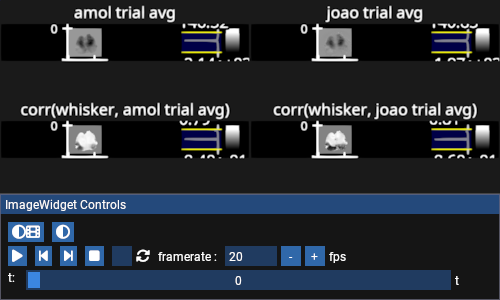

In [109]:
iw = fpl.ImageWidget(data = [amol_trial_avg, joao_trial_avg,
                             manual_mask * amol_trial_avg_corr, manual_mask * joao_trial_avg_corr,],
                     names= ['amol trial avg', 'joao trial avg', 'corr(whisker, amol trial avg)', 'corr(whisker, joao trial avg)'],
                    figure_shape = (2, 2))
iw.cmap = "gray"
iw.show()

In [62]:
joao_trial_avg = joao_trial_avg - np.mean(joao_trial_avg, axis = 0, keepdims = True)
amol_trial_avg = amol_trial_avg - np.mean(amol_trial_avg, axis = 0, keepdims = True)


In [51]:
# View results
iblwfci_vis.raster_view(amol_trial_avg, joao_trial_avg, 5)

In [16]:
trial_temp = trial_indices[:, None] + np.arange(-20, 80)[None, :]

In [20]:
trial_temp.flatten()

array([  1698,   1699,   1700, ..., 132422, 132423, 132424],
      shape=(85600,))

In [110]:
def trial_triggered_view(img_stack_1, 
                         img_stack_2, 
                         full_img_stack_1, 
                         full_img_stack_2, 
                         trial_data, 
                         before_event=20, 
                         after_event=80,
                        img_names = ['Amol', 'Joao'],
                        raster_names = ['Amol', 'Joao']):
    ## This gives a basic GUI that allows us to look at two sets of videos. Double click on the top panels and in the bottom panel a rastermap of a local region of pixels will pop up

    trial_indices = trial_data[:, None] + np.arange(-1*before_event, after_event)[None, :]
    trial_indices_f = trial_indices.flatten()
    
        
    num_frames = img_stack_1.shape[0]
    data_shape = img_stack_1.shape[1], img_stack_1.shape[2]
    
    start_coordinates = (data_shape[0] // 2, data_shape[1] // 2)

    def compute_raster_stack(my_stack, y, x):
        time_series = my_stack[:, y, x]
        z = time_series[trial_indices_f].reshape(trial_indices.shape)
        return z
        

    raster_1 = compute_raster_stack(full_img_stack_1, start_coordinates[0], start_coordinates[1])
    raster_2 = compute_raster_stack(full_img_stack_2, start_coordinates[0], start_coordinates[1])
    
    movie_widget = fpl.ImageWidget(data = [img_stack_1, 
                                    img_stack_2],
                           names = img_names)
    movie_widget.cmap = "gray"

    raster_widget = fpl.ImageWidget(data = [raster_1,
                                            raster_2],
                                    names = raster_names)
    raster_widget.cmap = "gray"

    rect_selector_kwargs = dict(
                edge_thickness=1,
                edge_color="w",
                vertex_size=3.0,
                vertex_color="cyan"
            )
    
    sel_1 = movie_widget.managed_graphics[0].add_rectangle_selector(
                    selection=[start_coordinates[1], start_coordinates[1] + 1, start_coordinates[0], start_coordinates[0] + 1],
                    **rect_selector_kwargs
                )
    
    sel_2 = movie_widget.managed_graphics[1].add_rectangle_selector(
                     selection=[start_coordinates[1], start_coordinates[1] + 1, start_coordinates[0], start_coordinates[0] + 1],
                    **rect_selector_kwargs
                )

    time_sel_1 = raster_widget.managed_graphics[0].add_linear_selector(0, axis="x")
    time_sel_2 = raster_widget.managed_graphics[1].add_linear_selector(0, axis="x")
    
    def update_values(ev):
        x, y = ev.pick_info['index']

        raster_1  = compute_raster_stack(full_img_stack_1, y, x)
        raster_2 = compute_raster_stack(full_img_stack_2, y, x)

    
        sel_1.selection = [x, x+1, y, y+1]
        sel_2.selection = [x, x+1, y, y+1]
        raster_widget.managed_graphics[0].data = raster_1
        raster_widget.managed_graphics[1].data = raster_2

        print(np.mean(np.var(raster_1, axis = 1)))
        print(np.mean(np.var(raster_2, axis = 1)))
        print("trial var")

    def temporal_sync(ev):
        ## First implementation will be selector --> widget (change the selector, update widget)

        ##In this case, the event came from imagewidget
        if isinstance(ev, dict):
            curr_index = int(ev['t'])
            time_sel_1.selection = curr_index
            time_sel_2.selection = curr_index
            
        else:
            curr_index = math.floor(ev.info['value'])

            time_sel_1.selection = curr_index
            time_sel_2.selection = curr_index
            movie_widget.current_index = {'t': curr_index}
    
    
    movie_widget.managed_graphics[0].add_event_handler(update_values, "double_click")
    movie_widget.managed_graphics[1].add_event_handler(update_values, "double_click")

    time_sel_1.add_event_handler(temporal_sync, "selection")
    time_sel_2.add_event_handler(temporal_sync, "selection")
    movie_widget.add_event_handler(temporal_sync, "current_index")
    
    
    return VBox([movie_widget.show(), raster_widget.show()])

In [111]:
trial_triggered_view(amol_trial_avg, 
                     joao_trial_avg,
                     hemocorr_pmd,
                     joao_hemocorr,
                     trial_indices)

RFBOutputContext()

RFBOutputContext()

474871.06
322899.1
trial var


In [67]:
joao_1 = joao_hemocorr[5000:7000]
joao_1 -= joao_hemocorr.mean_img.cpu().numpy()[None, :, :]

In [68]:
amol_1 = hemocorr_pmd[5000:7000]
amol_1 -= hemocorr_pmd.mean_img.cpu().numpy()[None, :, :]

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
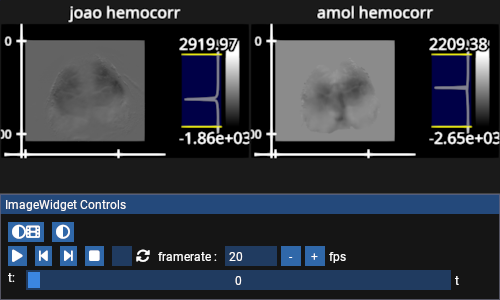

Error during handling pointer_up event: IM_ASSERT( mouse_button >= 0 … (3)
Error during handling pointer_up event: IM_ASSERT( mouse_button >= 0 … (4)
Error during handling pointer_up event: IM_ASSERT( mouse_button >= 0 … (5)
Error during handling pointer_up event: IM_ASSERT( mouse_button >= 0 … (7)


In [69]:
iw = fpl.ImageWidget(data = [joao_1, amol_1],
                     names = ['joao hemocorr', 'amol hemocorr'])
iw.cmap = "gray"
iw.show()

# Visualize the difference in image stacks generated from Amol vs. Joao method

In [ ]:
timeslice = slice(14000, 16000)
joao_subset = joao_hemocorr[timeslice]
joao_subset -= np.mean(joao_subset, axis = 0, keepdims=True)
amol_subset = hemocorr_pmd[timeslice]
amol_subset -= np.mean(amol_subset, axis = 0, keepdims=True)
diff = joao_subset - amol_subset
iw = fpl.ImageWidget(data = [joao_subset, amol_subset, diff],
                     names = ['joao mean0', 'amol mean0', 'diff'],
                     figure_shape = (1, 3))
iw.cmap = "gray"
iw.show()